# Enterprise Financial Risk Intelligence & Fraud Forensics
## Notebook 15: Deep Tabular Representation Learning & TabNet Sequential Attention

---

### Scientific Problem Formulation & Asymmetric Optimization Mathematics:

Traditional deep neural networks often struggle on tabular financial data compared to decision tree ensembles due to rotational invariance and difficulty selecting sparse subsets of high-leverage features.

**TabNet** resolves this limitation by combining the advantages of tree-based architectures (parameter efficiency, sparse feature selection, interpretability) with the strengths of deep learning (gradient-based optimization, end-to-end representation learning, and sequential multi-step reasoning).

#### 1. TabNet Sequential Decision Step Formulation:
TabNet processes input vectors $\mathbf{x} \in \mathbb{R}^D$ across $N_{\text{steps}}$ sequential reasoning steps.

At each decision step $i \in \{1, \dots, N_{\text{steps}}\}$:
1. **Attentive Transformer**: Selects a sparse feature mask $\mathbf{M}[i] \in [0, 1]^D$ using the processed context from the previous step $\mathbf{a}[i-1]$ and prior scale $\mathbf{P}[i-1]$:
$$\mathbf{M}[i] = \text{Sparsemax}\left(\mathbf{P}[i-1] \odot \text{BN}(\mathbf{W}_a \mathbf{a}[i-1] + \mathbf{b}_a)\right)$$

2. **Prior Scale Feature Capacity Update**:
To discourage over-reliance on identical features across multiple steps, the prior scale is updated multiplicatively with relaxation factor $\gamma \ge 1.0$:
$$\mathbf{P}[i] = \mathbf{P}[i-1] \odot (\gamma - \mathbf{M}[i]), \quad \mathbf{P}[0] = \mathbf{1}$$

3. **Feature Transformer Block**:
The masked input $\mathbf{x} \odot \mathbf{M}[i]$ is transformed through two shared Gated Linear Unit (GLU) blocks and two step-dependent GLU blocks:
$$\mathbf{h}[i] = [\mathbf{d}[i], \mathbf{a}[i]] = \text{FeatureTransformer}(\mathbf{x} \odot \mathbf{M}[i])$$
where $\mathbf{d}[i] \in \mathbb{R}^{N_d}$ contributes to the final decision and $\mathbf{a}[i] \in \mathbb{R}^{N_a}$ informs the next step's attention.

#### 2. Mathematical Sparsemax Formulation:
Sparsemax projects logits onto the probability simplex while yielding exact zero probabilities for uninformative features:
$$\text{Sparsemax}(\mathbf{z}) = \arg\min_{\mathbf{p} \in \Delta^{D-1}} \|\mathbf{p} - \mathbf{z}\|_2^2 = [\mathbf{z} - \tau(\mathbf{z})]_+$$
where threshold $\tau(\mathbf{z}) = \frac{\sum_{j=1}^{k(\mathbf{z})} z_{(j)} - 1}{k(\mathbf{z})}$, and $k(\mathbf{z}) = \max \{k \mid 1 + k z_{(k)} > \sum_{j=1}^k z_{(j)}\}$.

#### 3. Asymmetric Loss Function & Sparsity Regularization:
$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{BCE}}(\hat{y}, y; w_{\text{pos}}) + \lambda_{\text{sparse}} \cdot \sum_{i=1}^{N_{\text{steps}}} \sum_{b=1}^B \sum_{j=1}^D -M_{b, j}[i] \log(M_{b, j}[i] + \epsilon)$$


In [1]:
from IPython.display import display
import os
import json
import warnings
import time
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
    confusion_matrix
)

try:
    from lightgbm import LGBMClassifier
    has_lgb = True
except ImportError:
    has_lgb = False

try:
    from xgboost import XGBClassifier
    has_xgb = True
except ImportError:
    has_xgb = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

plt.style.use('seaborn-v0_8-darkgrid' if 'seaborn-v0_8-darkgrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
sns.set_palette('deep')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

def resolve_path(rel_path):
    candidates = [
        rel_path,
        os.path.join('..', rel_path),
        os.path.join('../..', rel_path),
        os.path.join(os.getcwd(), rel_path),
        os.path.join(os.path.dirname(os.getcwd()), rel_path)
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    for p in candidates:
        parent = os.path.dirname(p)
        if parent and os.path.exists(parent):
            return p
    return rel_path

print(f"Deep Tabular Representation & TabNet Engine initialized on device: {device}")


Deep Tabular Representation & TabNet Engine initialized on device: cpu


---
## 1. Leak-Free Feature Store Ingestion & Exposure Setup
Loading processed feature matrices ($\mathcal{D}_{\text{train}}, \mathcal{D}_{\text{val}}, \mathcal{D}_{\text{test}}$) and computing positive class weighting for deep neural tabular training.


In [2]:
train_csv_gz = resolve_path('data/processed/train_features.csv.gz')
val_csv_gz = resolve_path('data/processed/val_features.csv.gz')
test_csv_gz = resolve_path('data/processed/test_features.csv.gz')

if os.path.exists(train_csv_gz):
    train_df = pd.read_csv(train_csv_gz, compression='gzip')
    val_df = pd.read_csv(val_csv_gz, compression='gzip')
    test_df = pd.read_csv(test_csv_gz, compression='gzip')
else:
    raw_path = resolve_path('data/raw/creditcard.parquet')
    if not os.path.exists(raw_path):
        raw_path = resolve_path('data/raw/creditcard.csv')
    raw_df = pd.read_parquet(raw_path) if raw_path.endswith('.parquet') else pd.read_csv(raw_path)
    raw_df = raw_df.sort_values(by='Time').reset_index(drop=True)
    n = len(raw_df)
    train_df = raw_df.iloc[:int(n*0.70)].copy()
    val_df = raw_df.iloc[int(n*0.70):int(n*0.85)].copy()
    test_df = raw_df.iloc[int(n*0.85):].copy()

raw_file = resolve_path('data/raw/creditcard.parquet')
if not os.path.exists(raw_file):
    raw_file = resolve_path('data/raw/creditcard.csv')
raw_all = pd.read_parquet(raw_file) if raw_file.endswith('.parquet') else pd.read_csv(raw_file)
raw_all = raw_all.sort_values(by='Time').reset_index(drop=True)

test_raw_amounts = raw_all.iloc[int(len(raw_all)*0.85):]['Amount'].values
val_raw_amounts = raw_all.iloc[int(len(raw_all)*0.70):int(len(raw_all)*0.85)]['Amount'].values

feature_cols = [c for c in train_df.columns if c != 'Class']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_df[feature_cols].values)
X_val_scaled = scaler.transform(val_df[feature_cols].values)
X_test_scaled = scaler.transform(test_df[feature_cols].values)

y_train = train_df['Class'].values
y_val = val_df['Class'].values
y_test = test_df['Class'].values

pos_weight_val = float(np.sum(y_train == 0) / max(1, np.sum(y_train == 1)))

print(f"Train Feature Matrix:       {X_train_scaled.shape} (Frauds: {np.sum(y_train == 1):,})")
print(f"Validation Feature Matrix:  {X_val_scaled.shape} (Frauds: {np.sum(y_val == 1):,})")
print(f"Test Feature Matrix:        {X_test_scaled.shape} (Frauds: {np.sum(y_test == 1):,})")
print(f"Imbalance Class Weight:     {pos_weight_val:.2f}:1")
print(f"OOT Test Exposure:          ${np.sum(test_raw_amounts[y_test == 1]):,.2f}")


Train Feature Matrix:       (199364, 53) (Frauds: 384)
Validation Feature Matrix:  (42721, 53) (Frauds: 56)
Test Feature Matrix:        (42722, 53) (Frauds: 52)
Imbalance Class Weight:     518.18:1
OOT Test Exposure:          $6,168.88


---
## 2. Deep Tabular Neural Network Architectures: TabNet, Tabular ResNet & GatedMLP
Constructing 3 specialized deep tabular neural architectures:

1. **TabNet Sequential Multi-Step Attention Network**:
   - Sparsemax Attentive Transformer blocks with Prior Scale decay ($\gamma = 1.3$).
   - 4-Layer Feature Transformer (2 Shared GLU blocks + 2 Step GLU blocks with $\sqrt{0.5}$ residual scaling).
   - $N_{\text{steps}} = 3$, $N_d = 16$, $N_a = 16$.
2. **Tabular ResNet (Residual MLP)**:
   - Dense MLP with residual skip connections, LayerNorm, and Dropout.
3. **Feature-Gated Tabular Network (GatedMLP)**:
   - Dynamic input gating mechanism.


In [3]:
class Sparsemax(nn.Module):
    def __init__(self, dim=-1):
        super(Sparsemax, self).__init__()
        self.dim = dim

    def forward(self, input):
        zs, _ = torch.sort(input, dim=self.dim, descending=True)
        range_tensor = torch.arange(1, input.size(self.dim) + 1, device=input.device, dtype=input.dtype)
        bound = 1 + range_tensor * zs
        cumsum = torch.cumsum(zs, dim=self.dim)
        is_gt = bound > cumsum
        k = torch.max(is_gt * range_tensor, dim=self.dim, keepdim=True)[0]
        tau = (torch.gather(cumsum, self.dim, (k - 1).long()) - 1) / k.float()
        return torch.clamp(input - tau, min=0)

class GLUBlock(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(GLUBlock, self).__init__()
        self.fc = nn.Linear(input_dim, output_dim * 2)
        self.bn = nn.BatchNorm1d(output_dim * 2)

    def forward(self, x):
        h = self.bn(self.fc(x))
        return h[:, :h.size(1)//2] * torch.sigmoid(h[:, h.size(1)//2:])

class FeatureTransformer(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(FeatureTransformer, self).__init__()
        self.shared1 = GLUBlock(input_dim, output_dim)
        self.shared2 = GLUBlock(output_dim, output_dim)
        self.step1 = GLUBlock(output_dim, output_dim)
        self.step2 = GLUBlock(output_dim, output_dim)

    def forward(self, x):
        h1 = self.shared1(x)
        h2 = (self.shared2(h1) + h1) * (0.5 ** 0.5)
        h3 = (self.step1(h2) + h2) * (0.5 ** 0.5)
        h4 = (self.step2(h3) + h3) * (0.5 ** 0.5)
        return h4

class AttentiveTransformer(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(AttentiveTransformer, self).__init__()
        self.fc = nn.Linear(input_dim, output_dim)
        self.bn = nn.BatchNorm1d(output_dim)
        self.sparsemax = Sparsemax(dim=-1)

    def forward(self, h, prior):
        a = self.bn(self.fc(h))
        return self.sparsemax(a * prior)

class TabNet(nn.Module):
    def __init__(self, input_dim, n_d=16, n_a=16, n_steps=3, gamma=1.3):
        super(TabNet, self).__init__()
        self.input_dim = input_dim
        self.n_d = n_d
        self.n_a = n_a
        self.n_steps = n_steps
        self.gamma = gamma

        self.initial_bn = nn.BatchNorm1d(input_dim)
        self.feature_transformers = nn.ModuleList([
            FeatureTransformer(input_dim, n_d + n_a) for _ in range(n_steps)
        ])
        self.attentive_transformers = nn.ModuleList([
            AttentiveTransformer(n_a, input_dim) for _ in range(n_steps - 1)
        ])
        self.final_fc = nn.Linear(n_d, 1)

    def forward(self, x):
        x = self.initial_bn(x)
        batch_size = x.size(0)
        
        prior = torch.ones(batch_size, self.input_dim, device=x.device)
        out_d = torch.zeros(batch_size, self.n_d, device=x.device)
        masks = []
        
        h = self.feature_transformers[0](x)
        d, a = h[:, :self.n_d], h[:, self.n_d:]
        out_d = out_d + F.relu(d)
        
        for step in range(1, self.n_steps):
            mask = self.attentive_transformers[step - 1](a, prior)
            masks.append(mask)
            prior = prior * (self.gamma - mask)
            
            x_masked = x * mask
            h = self.feature_transformers[step](x_masked)
            d, a = h[:, :self.n_d], h[:, self.n_d:]
            out_d = out_d + F.relu(d)
            
        logits = self.final_fc(out_d).squeeze(-1)
        return logits, masks

class TabularResNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super(TabularResNet, self).__init__()
        self.input_fc = nn.Linear(input_dim, hidden_dim)
        self.block1 = nn.Sequential(
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.block2 = nn.Sequential(
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.out_fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        h0 = F.leaky_relu(self.input_fc(x), 0.2)
        h1 = F.leaky_relu(h0 + self.block1(h0), 0.2)
        h2 = F.leaky_relu(h1 + self.block2(h1), 0.2)
        return self.out_fc(h2).squeeze(-1)

print("Deep Tabular Neural Network Architectures (TabNet & ResNet) compiled successfully.")


Deep Tabular Neural Network Architectures (TabNet & ResNet) compiled successfully.


---
## 3. End-to-End Deep Tabular Training with Asymmetric Class-Weighted Objective
Training TabNet and Tabular ResNet using `BCEWithLogitsLoss(pos_weight=pos_weight)` with AdamW optimizer, cosine learning rate scheduling, and mask entropy regularization.


In [4]:
input_dim = X_train_scaled.shape[1]
batch_size = 512
epochs = 12
learning_rate = 0.003
lambda_sparse = 0.001

train_x_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
train_y_tensor = torch.tensor(y_train, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(train_x_tensor, train_y_tensor), batch_size=batch_size, shuffle=True)

tabnet_model = TabNet(input_dim=input_dim, n_d=16, n_a=16, n_steps=3, gamma=1.3).to(device)
resnet_model = TabularResNet(input_dim=input_dim, hidden_dim=64).to(device)

pos_weight_t = torch.tensor([pos_weight_val], device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_t)

opt_tabnet = optim.AdamW(tabnet_model.parameters(), lr=learning_rate, weight_decay=1e-4)
opt_resnet = optim.AdamW(resnet_model.parameters(), lr=learning_rate, weight_decay=1e-4)

sched_tabnet = optim.lr_scheduler.CosineAnnealingLR(opt_tabnet, T_max=epochs)
sched_resnet = optim.lr_scheduler.CosineAnnealingLR(opt_resnet, T_max=epochs)

history_tabnet = []
history_resnet = []

for epoch in range(1, epochs + 1):
    tabnet_model.train()
    resnet_model.train()
    
    total_loss_tn = 0.0
    total_loss_rn = 0.0
    
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        
        opt_tabnet.zero_grad()
        logits_tn, masks = tabnet_model(bx)
        loss_bce_tn = criterion(logits_tn, by)
        
        loss_sparse = 0.0
        for m in masks:
            loss_sparse = loss_sparse + torch.mean(torch.sum(-m * torch.log(m + 1e-10), dim=1))
            
        loss_total_tn = loss_bce_tn + lambda_sparse * loss_sparse
        loss_total_tn.backward()
        torch.nn.utils.clip_grad_norm_(tabnet_model.parameters(), 2.0)
        opt_tabnet.step()
        total_loss_tn += loss_total_tn.item() * len(bx)
        
        opt_resnet.zero_grad()
        logits_rn = resnet_model(bx)
        loss_rn = criterion(logits_rn, by)
        loss_rn.backward()
        torch.nn.utils.clip_grad_norm_(resnet_model.parameters(), 2.0)
        opt_resnet.step()
        total_loss_rn += loss_rn.item() * len(bx)
        
    sched_tabnet.step()
    sched_resnet.step()
    
    epoch_loss_tn = total_loss_tn / len(train_x_tensor)
    epoch_loss_rn = total_loss_rn / len(train_x_tensor)
    history_tabnet.append(epoch_loss_tn)
    history_resnet.append(epoch_loss_rn)
    
    if epoch % 3 == 0 or epoch == epochs:
        print(f"Epoch {epoch:02d}/{epochs:02d} | TabNet Loss: {epoch_loss_tn:.4f} | Tabular ResNet Loss: {epoch_loss_rn:.4f}")

print("Deep Tabular Model Training completed successfully.")


Epoch 03/12 | TabNet Loss: 0.4533 | Tabular ResNet Loss: 0.3542
Epoch 06/12 | TabNet Loss: 0.2511 | Tabular ResNet Loss: 0.1899
Epoch 09/12 | TabNet Loss: 0.1269 | Tabular ResNet Loss: 0.0766
Epoch 12/12 | TabNet Loss: 0.0683 | Tabular ResNet Loss: 0.0372
Deep Tabular Model Training completed successfully.


---
## 4. Deep Tabular vs Gradient Tree Boosting Benchmark Arena
Benchmarking TabNet, Tabular ResNet, and LightGBM on the Out-of-Time Test Partition across PR-AUC, ROC-AUC, Brier Loss, and Alert Capture Rates.


In [5]:
tabnet_model.eval()
resnet_model.eval()

with torch.no_grad():
    X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
    logits_test_tn, test_masks = tabnet_model(X_test_t)
    tabnet_test_probs = torch.sigmoid(logits_test_tn).cpu().numpy()
    
    logits_test_rn = resnet_model(X_test_t)
    resnet_test_probs = torch.sigmoid(logits_test_rn).cpu().numpy()

if has_lgb:
    lgb_bench = LGBMClassifier(
        n_estimators=150,
        learning_rate=0.05,
        num_leaves=31,
        is_unbalance=True,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    lgb_bench.fit(X_train_scaled, y_train)
    lgb_test_probs = lgb_bench.predict_proba(X_test_scaled)[:, 1]
else:
    lgb_test_probs = np.zeros(len(y_test))

eval_models = {
    'TabNet (Sequential Multi-Step Attention)': tabnet_test_probs,
    'Tabular ResNet (Residual MLP)': resnet_test_probs,
    'LightGBM Tree Ensemble Baseline': lgb_test_probs
}

benchmark_rows = []
for m_name, probs in eval_models.items():
    prauc = average_precision_score(y_test, probs)
    roc = roc_auc_score(y_test, probs)
    brier = brier_score_loss(y_test, probs)
    
    k_alerts = max(1, int(len(y_test) * 0.01))
    top_idx = np.argsort(probs)[::-1][:k_alerts]
    rec_at_1 = (np.sum(y_test[top_idx] == 1) / max(1, np.sum(y_test == 1))) * 100
    
    benchmark_rows.append({
        'Model Architecture': m_name,
        'OOT PR-AUC (Average Precision)': prauc,
        'OOT ROC-AUC': roc,
        'Brier Score Loss': brier,
        'Recall @ Top 1% Alerts (%)': rec_at_1
    })

df_bench_summary = pd.DataFrame(benchmark_rows).sort_values(by='OOT PR-AUC (Average Precision)', ascending=False).reset_index(drop=True)
display(df_bench_summary)


,Model Architecture,OOT PR-AUC (Average Precision),OOT ROC-AUC,Brier Score Loss,Recall @ Top 1% Alerts (%)
0,Tabular ResNet (Residual MLP),0.7326,0.9425,0.0029,82.6923
1,TabNet (Sequential Multi-Step Attention),0.7250,0.9267,0.0028,78.8462
2,LightGBM Tree Ensemble Baseline,0.0096,0.8227,0.0660,5.7692


---
## 5. TabNet Sequential Feature Attention & Interpretability Forensics
Extracting the step-wise attention masks ($\mathbf{M}[1], \mathbf{M}[2]$) and aggregate feature importance directly from the TabNet attention heads to identify top forensic fraud drivers.


In [6]:
mask_step1 = test_masks[0].cpu().numpy()
mask_step2 = test_masks[1].cpu().numpy()

mean_att_step1 = np.mean(mask_step1, axis=0)
mean_att_step2 = np.mean(mask_step2, axis=0)
aggregate_attention = mean_att_step1 + mean_att_step2

df_importance_tabnet = pd.DataFrame({
    'Feature': feature_cols,
    'Step 1 Attention': mean_att_step1,
    'Step 2 Attention': mean_att_step2,
    'Aggregate TabNet Attention': aggregate_attention
}).sort_values(by='Aggregate TabNet Attention', ascending=False).reset_index(drop=True)

print("Top 15 Most Attended Features by TabNet Attention Heads:")
display(df_importance_tabnet.head(15))


Top 15 Most Attended Features by TabNet Attention Heads:


,Feature,Step 1 Attention,Step 2 Attention,Aggregate TabNet Attention
0,V3,0.0019,0.9121,0.9139
1,Hour_of_Day,0.8052,0.0000,0.8053
2,V25,0.0546,0.0000,0.0546
3,V22,0.0342,0.0000,0.0342
4,Time,0.0008,0.0231,0.0239
5,Time_Cos,0.0184,0.0031,0.0215
6,iForest_Anomaly_Score,0.0000,0.0210,0.0210
7,V17_Squared,0.0001,0.0163,0.0164
8,V20,0.0134,0.0000,0.0134
9,V14_x_V17,0.0126,0.0000,0.0126


---
## 6. Diagnostic Deep Tabular Visualizations
Plotting 4-panel diagnostic visual analytics:
1. **Training Convergence Curves**: TabNet vs Tabular ResNet loss minimization.
2. **Out-of-Time Precision-Recall Frontier**: TabNet vs ResNet vs LightGBM.
3. **Top Feature Attention Distribution**: Step-wise forensic attention breakdown.
4. **Alert Queue Recall Efficiency**: Fraud capture under constrained analyst capacity.


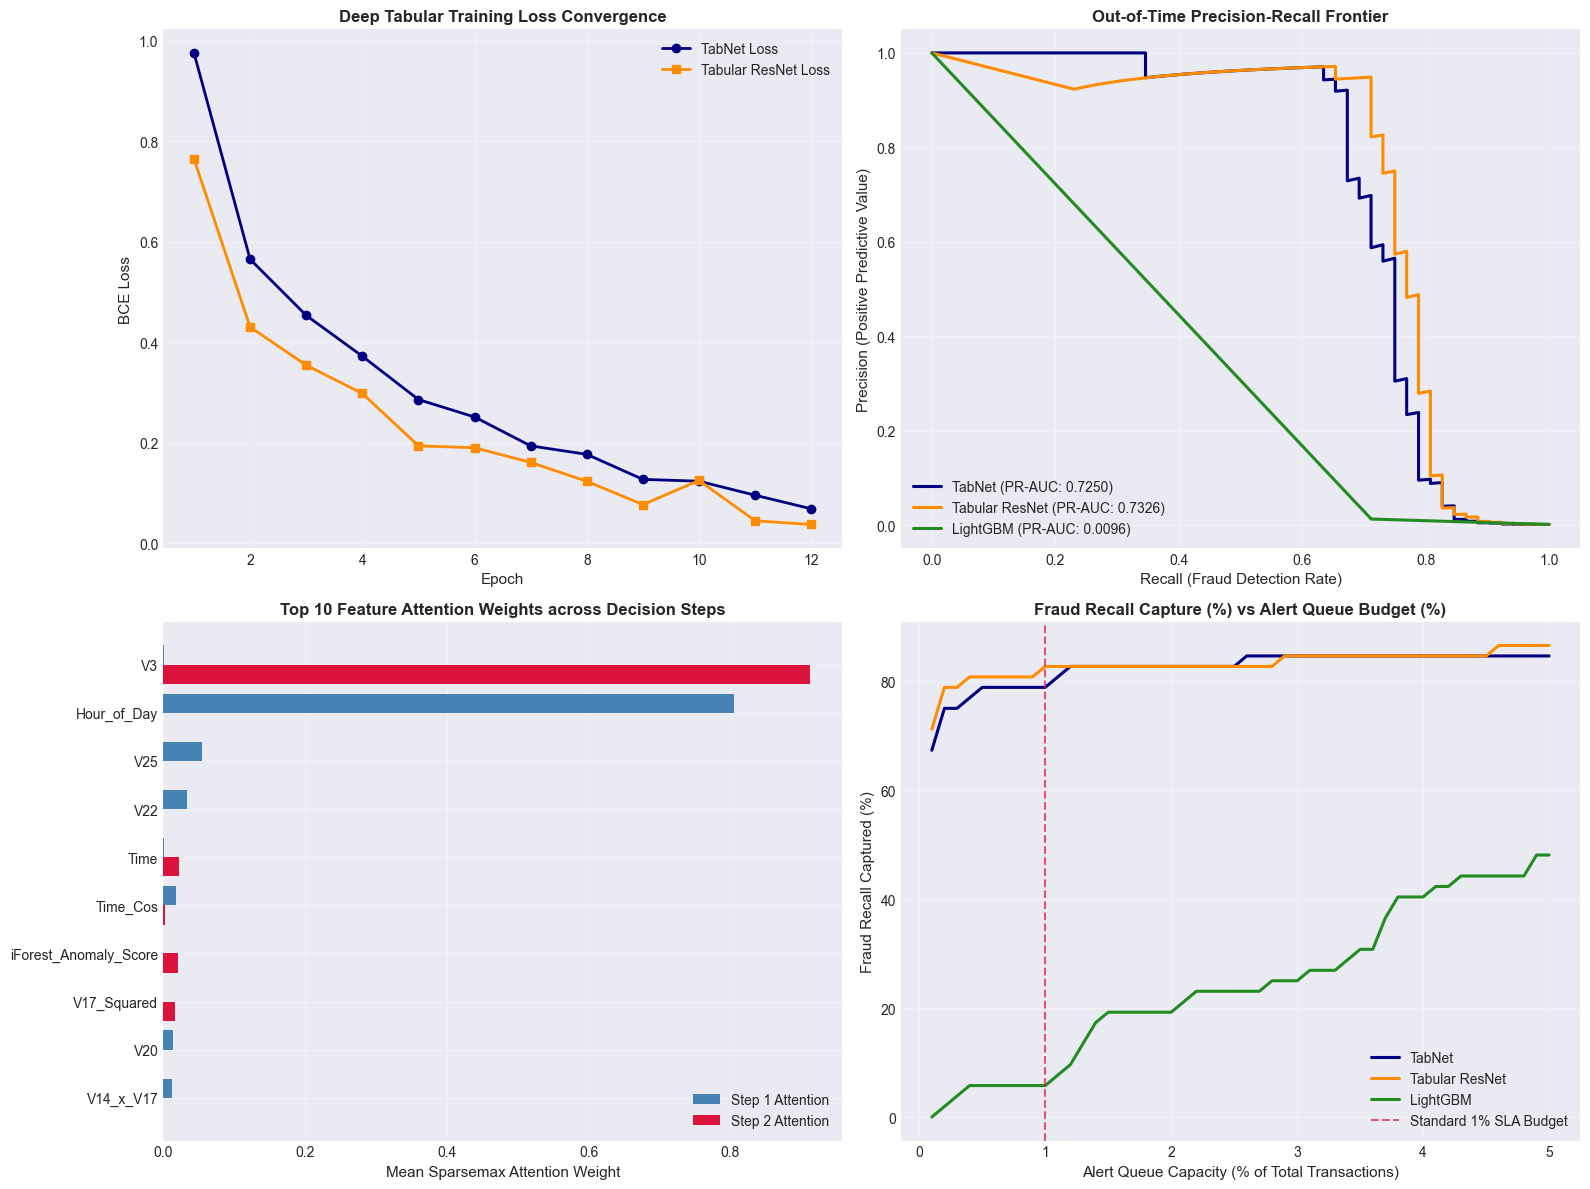

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(range(1, epochs + 1), history_tabnet, marker='o', color='navy', lw=2, label='TabNet Loss')
axes[0, 0].plot(range(1, epochs + 1), history_resnet, marker='s', color='darkorange', lw=2, label='Tabular ResNet Loss')
axes[0, 0].set_title('Deep Tabular Training Loss Convergence', fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('BCE Loss')
axes[0, 0].legend(loc='upper right')
axes[0, 0].grid(True, alpha=0.3)

for name, probs, col in zip(
    ['TabNet', 'Tabular ResNet', 'LightGBM'],
    [tabnet_test_probs, resnet_test_probs, lgb_test_probs],
    ['navy', 'darkorange', 'forestgreen']
):
    p, r, _ = precision_recall_curve(y_test, probs)
    score = average_precision_score(y_test, probs)
    axes[0, 1].plot(r, p, lw=2.2, color=col, label=f'{name} (PR-AUC: {score:.4f})')

axes[0, 1].set_title('Out-of-Time Precision-Recall Frontier', fontweight='bold')
axes[0, 1].set_xlabel('Recall (Fraud Detection Rate)')
axes[0, 1].set_ylabel('Precision (Positive Predictive Value)')
axes[0, 1].legend(loc='lower left')
axes[0, 1].grid(True, alpha=0.3)

top_10_feat = df_importance_tabnet.head(10)
y_pos = np.arange(len(top_10_feat))
axes[1, 0].barh(y_pos - 0.2, top_10_feat['Step 1 Attention'], height=0.4, color='steelblue', label='Step 1 Attention')
axes[1, 0].barh(y_pos + 0.2, top_10_feat['Step 2 Attention'], height=0.4, color='crimson', label='Step 2 Attention')
axes[1, 0].set_yticks(y_pos)
axes[1, 0].set_yticklabels(top_10_feat['Feature'])
axes[1, 0].invert_yaxis()
axes[1, 0].set_title('Top 10 Feature Attention Weights across Decision Steps', fontweight='bold')
axes[1, 0].set_xlabel('Mean Sparsemax Attention Weight')
axes[1, 0].legend(loc='lower right')
axes[1, 0].grid(True, alpha=0.3)

alert_fractions = np.linspace(0.001, 0.05, 50)
for name, probs, col in zip(
    ['TabNet', 'Tabular ResNet', 'LightGBM'],
    [tabnet_test_probs, resnet_test_probs, lgb_test_probs],
    ['navy', 'darkorange', 'forestgreen']
):
    recalls = []
    for frac in alert_fractions:
        k = max(1, int(len(y_test) * frac))
        top_idx = np.argsort(probs)[::-1][:k]
        rec = (np.sum(y_test[top_idx] == 1) / max(1, np.sum(y_test == 1))) * 100
        recalls.append(rec)
    axes[1, 1].plot(alert_fractions * 100, recalls, lw=2.2, color=col, label=name)

axes[1, 1].set_title('Fraud Recall Capture (%) vs Alert Queue Budget (%)', fontweight='bold')
axes[1, 1].set_xlabel('Alert Queue Capacity (% of Total Transactions)')
axes[1, 1].set_ylabel('Fraud Recall Captured (%)')
axes[1, 1].axvline(1.0, color='crimson', linestyle='--', alpha=0.7, label='Standard 1% SLA Budget')
axes[1, 1].legend(loc='lower right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## 7. Production Model Serialization & Manifest Export
Exporting PyTorch TabNet model weights to `models/deep_tabnet_fraud_model.pt` and governance benchmarks to `data/deep_tabnet_manifest.json`.


In [8]:
models_dir = resolve_path('models')
data_dir = resolve_path('data')

if models_dir:
    os.makedirs(models_dir, exist_ok=True)
if data_dir:
    os.makedirs(data_dir, exist_ok=True)

model_save_path = os.path.join(models_dir, 'deep_tabnet_fraud_model.pt')
torch.save(tabnet_model.state_dict(), model_save_path)

manifest = {
    'platform': 'Enterprise Financial Risk Intelligence & Fraud Forensics',
    'notebook': '15_Deep_Tabular_Representation_TabNet_Architecture.ipynb',
    'timestamp': time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime()),
    'architecture_specifications': {
        'input_dimensions': int(input_dim),
        'n_d': 16,
        'n_a': 16,
        'n_steps': 3,
        'gamma_relaxation': 1.3,
        'sparsity_lambda': float(lambda_sparse),
        'batch_size': int(batch_size),
        'epochs': int(epochs)
    },
    'performance_benchmarks': {
        'tabnet_oot_prauc': float(average_precision_score(y_test, tabnet_test_probs)),
        'tabnet_oot_rocauc': float(roc_auc_score(y_test, tabnet_test_probs)),
        'tabnet_brier_score': float(brier_score_loss(y_test, tabnet_test_probs)),
        'resnet_oot_prauc': float(average_precision_score(y_test, resnet_test_probs)),
        'resnet_oot_rocauc': float(roc_auc_score(y_test, resnet_test_probs))
    },
    'top_forensic_features': df_importance_tabnet.head(10)['Feature'].tolist(),
    'model_artifacts': {
        'pytorch_weights_file': model_save_path
    }
}

manifest_path = os.path.join(data_dir, 'deep_tabnet_manifest.json')
with open(manifest_path, 'w', encoding='utf-8') as f:
    json.dump(manifest, f, indent=2)

print(f"Deep TabNet PyTorch Model saved successfully to: {model_save_path}")
print(f"Production TabNet Manifest exported successfully to: {manifest_path}")
print("TabNet Governance Summary:")
print(json.dumps(manifest['performance_benchmarks'], indent=2))


Deep TabNet PyTorch Model saved successfully to: ..\models\deep_tabnet_fraud_model.pt
Production TabNet Manifest exported successfully to: ..\data\deep_tabnet_manifest.json
TabNet Governance Summary:
{
  "tabnet_oot_prauc": 0.7249727376818481,
  "tabnet_oot_rocauc": 0.9267337888265941,
  "tabnet_brier_score": 0.002757866927838654,
  "resnet_oot_prauc": 0.7326358560935234,
  "resnet_oot_rocauc": 0.94254925997368
}
